# Прогноз времени выполнения производственного задания

Учебный проект (ML-Professional) на основе доменной модели реального ERP-проекта
для производства (ASPMK): заказы → изделия → маршрутные листы →
производственные задания → назначения рабочим.

**Задача:** по параметрам задания (нормо-время, рабочий, цех, изделие, смена, день недели)
предсказать **фактическое время выполнения** (`actual_minutes`).

Датасет синтетический, но сгенерирован так, чтобы воспроизводить реальные зависимости:
навык рабочего, несоответствие специальности цеху, ночная смена, понедельник/пятница,
перегрузка по объёму — всё это скрыто зашумляет норму времени, и модель должна это выучить.

Структура ноутбука:
1. Загрузка данных
2. EDA (разведочный анализ)
3. Feature engineering
4. Baseline: линейная регрессия
5. Дерево решений (с интерпретацией правил)
6. Градиентный бустинг (CatBoost / GradientBoosting)
7. Метод опорных векторов (SVR) — сравнение на уменьшенной выборке
8. Понижение размерности (PCA) + кластеризация рабочих (иерархическая, DBSCAN)
9. Борьба с переобучением: train vs validation, кривая обучения
10. Итоговое сравнение моделей, финальная проверка на test и выводы


## 1. Загрузка данных

In [1]:
# В Google Colab: загрузите data/production_tasks.csv через файловую панель слева,
# либо примонтируйте Google Drive, либо загрузите напрямую из GitHub (если репозиторий запушен).

# Вариант А: загрузка вручную в Colab
# from google.colab import files
# uploaded = files.upload()  # выберите production_tasks.csv

# Вариант Б: если репозиторий на GitHub (замените на свой raw-URL)
# import pandas as pd
# df = pd.read_csv("https://raw.githubusercontent.com/<user>/<repo>/main/production_time_prediction/data/production_tasks.csv")

import pandas as pd
import numpy as np

df = pd.read_csv("data/production_tasks.csv")
print(df.shape)
df.head()


(12000, 15)


,task_id,task_date,weekday,shift,workshop,worker_id,worker_speciality,required_speciality,speciality_mismatch,worker_experience_years,product_id,product_group,quantity,norm_minutes,actual_minutes
0,1,2025-04-22,1,day,Цех раскроя,58,Раскройщик,Раскройщик,0,11.0,28,Короб картонный,387,1941,2178
1,2,2025-03-09,6,night,Цех сборки,22,Сборщик,Сборщик,0,5.0,30,Упаковка подарочная,474,735,900
2,3,2025-03-19,2,night,Цех покраски,14,Маляр,Маляр,0,2.0,29,Короб картонный,437,627,718
3,4,2025-01-09,3,day,Цех сборки,22,Сборщик,Сборщик,0,5.0,20,Упаковка подарочная,467,1254,1509
4,5,2025-04-24,3,night,Цех контроля,35,Контролёр ОТК,Контролёр ОТК,0,8.0,13,Ящик пластиковый,348,693,948


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_id                  12000 non-null  int64  
 1   task_date                12000 non-null  str    
 2   weekday                  12000 non-null  int64  
 3   shift                    12000 non-null  str    
 4   workshop                 12000 non-null  str    
 5   worker_id                12000 non-null  int64  
 6   worker_speciality        12000 non-null  str    
 7   required_speciality      12000 non-null  str    
 8   speciality_mismatch      12000 non-null  int64  
 9   worker_experience_years  11640 non-null  float64
 10  product_id               12000 non-null  int64  
 11  product_group            12000 non-null  str    
 12  quantity                 12000 non-null  int64  
 13  norm_minutes             12000 non-null  int64  
 14  actual_minutes           12000 no

In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
task_id,12000.0,NaN,NaN,NaN,6000.5,3464.24595,1.0,3000.75,6000.5,9000.25,12000.0
task_date,12000,260,2025-02-08,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekday,12000.0,NaN,NaN,NaN,3.013417,2.007919,0.0,1.0,3.0,5.0,6.0
shift,12000,2,day,9071,NaN,NaN,NaN,NaN,NaN,NaN,NaN
workshop,12000,5,Цех покраски,2439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
worker_id,12000.0,NaN,NaN,NaN,31.087167,16.718992,1.0,17.0,32.0,45.0,60.0
worker_speciality,12000,5,Маляр,2491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_speciality,12000,5,Маляр,2439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
speciality_mismatch,12000.0,NaN,NaN,NaN,0.03975,0.195379,0.0,0.0,0.0,0.0,1.0
worker_experience_years,11640.0,NaN,NaN,NaN,9.423282,5.168054,0.0,5.0,9.0,14.0,19.0


## 2. EDA (разведочный анализ)

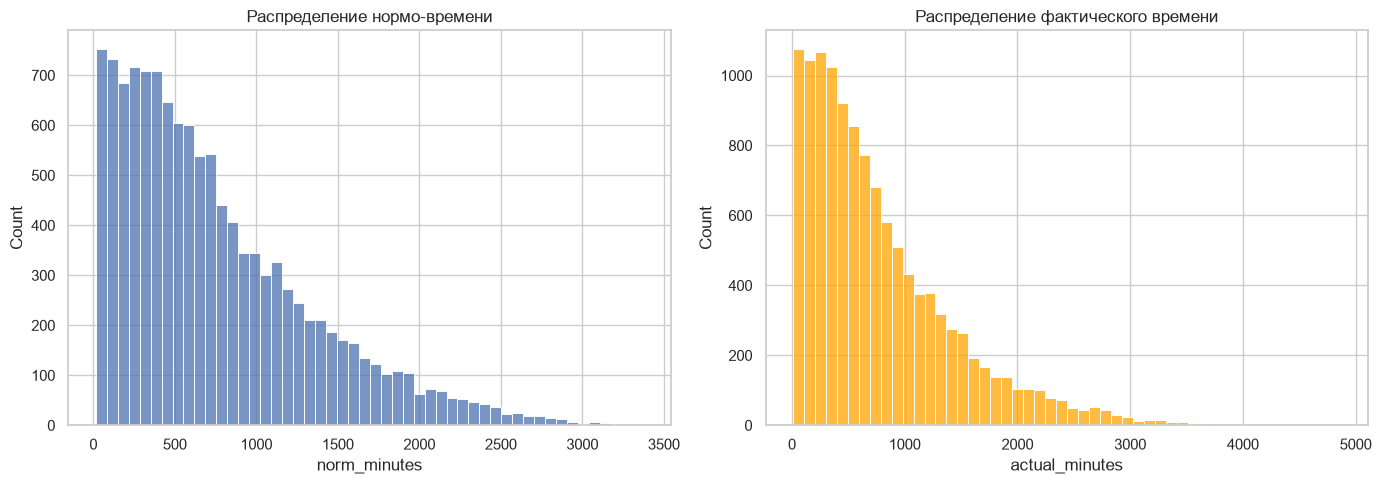

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Визуализация распределения нормо-времени и фактического времени
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["norm_minutes"], bins=50, ax=axes[0])
axes[0].set_title("Распределение нормо-времени")
sns.histplot(df["actual_minutes"], bins=50, ax=axes[1], color="orange")
axes[1].set_title("Распределение фактического времени")
plt.tight_layout()
plt.show()


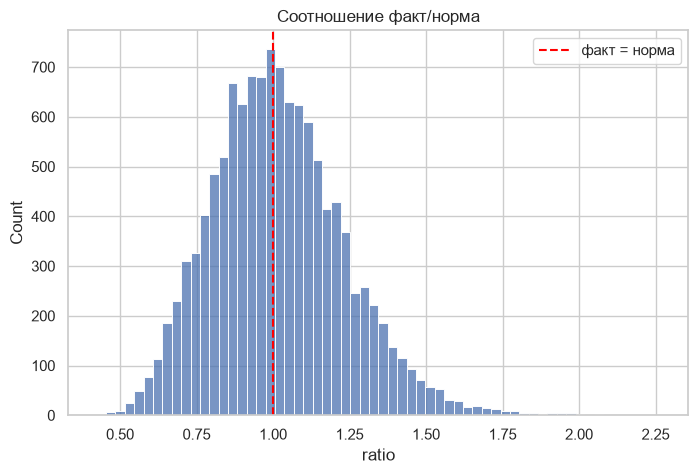

count    12000.000000
mean         1.017016
std          0.217654
min          0.423303
25%          0.865093
50%          1.000000
75%          1.148433
max          2.265306
Name: ratio, dtype: float64


In [5]:
# Целевая переменная для моделирования: отклонение факта от нормы (в разах)
df["ratio"] = df["actual_minutes"] / df["norm_minutes"]

plt.figure(figsize=(8, 5))
sns.histplot(df["ratio"], bins=60)
plt.axvline(1.0, color="red", linestyle="--", label="факт = норма")
plt.title("Соотношение факт/норма")
plt.legend()
plt.show()

print(df["ratio"].describe())


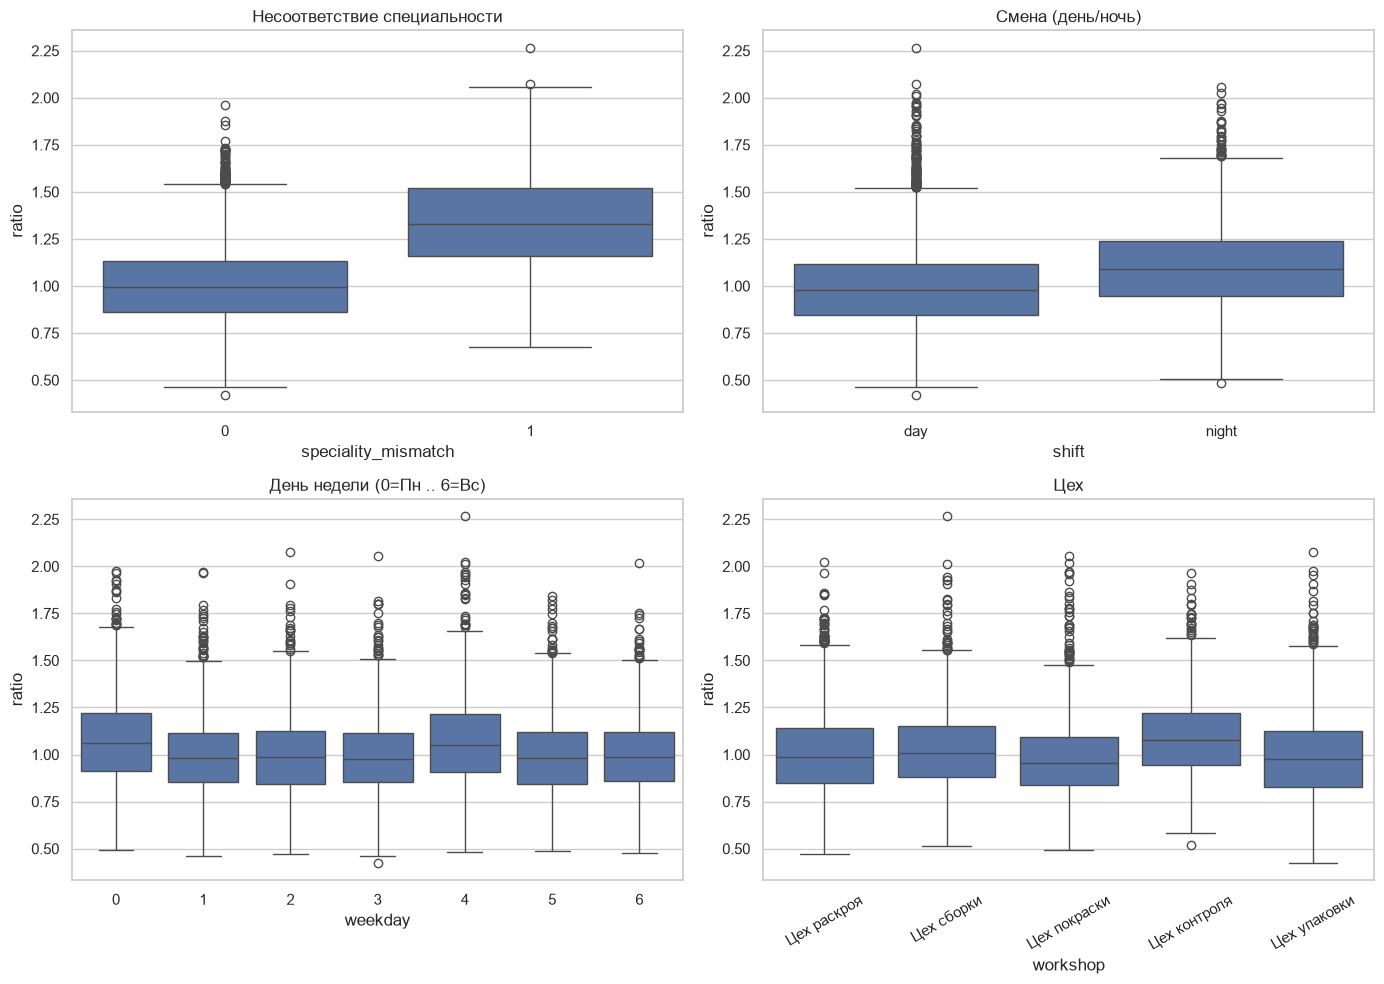

In [ ]:
# Влияние ключевых факторов на ratio
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Влияние несоответствия специальности, смены, дня недели и цеха на отношение фактического времени к нормо-времени (ratio)
sns.boxplot(data=df, x="speciality_mismatch", y="ratio", ax=axes[0, 0])
axes[0, 0].set_title("Несоответствие специальности")

sns.boxplot(data=df, x="shift", y="ratio", ax=axes[0, 1])
axes[0, 1].set_title("Смена (день/ночь)")

sns.boxplot(data=df, x="weekday", y="ratio", ax=axes[1, 0])
axes[1, 0].set_title("День недели (0=Пн .. 6=Вс)")

sns.boxplot(data=df, x="workshop", y="ratio", ax=axes[1, 1])
axes[1, 1].set_title("Цех")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


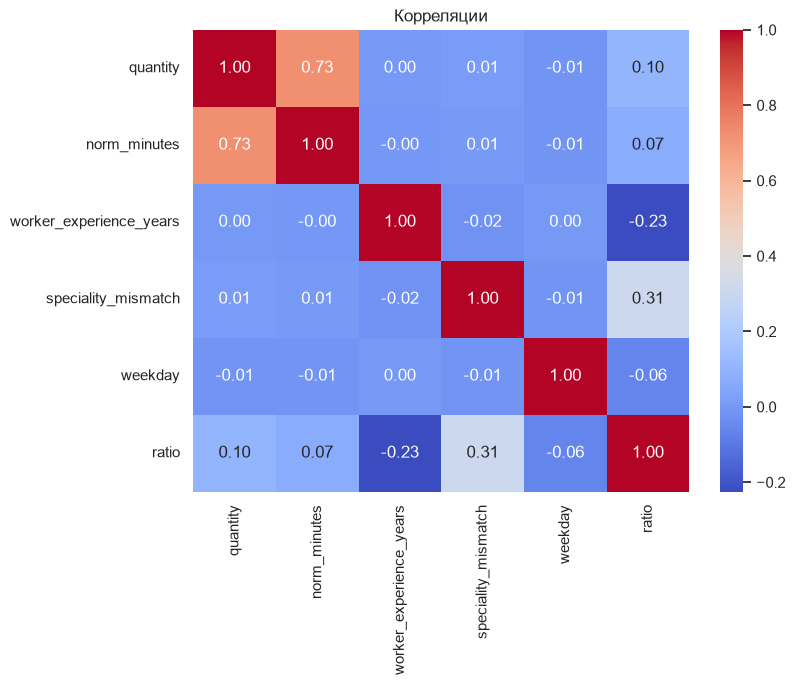

In [ ]:
# Тепловая карта корреляций числовых признаков
# колонка с числовыми признаками для корреляции
num_cols = ["quantity", "norm_minutes", "worker_experience_years", "speciality_mismatch", "weekday", "ratio"]
plt.figure(figsize=(8, 6))
# построение тепловой карты корреляций числовых признаков
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляции")
plt.show()


## 3. Feature engineering

Добавляем признаки, которые в реальном проекте легко вычислить из `task_assignments` /
`production_tasks` без дополнительного сбора данных:
- `is_weekend_adjacent` — понедельник/пятница (эффект "разгона"/"усталости")
- `is_night` — ночная смена
- `quantity_per_norm_minute` — интенсивность операции
- целевая переменная: `actual_minutes` (регрессия) — но обучаем модель на `log(actual_minutes)`,
  чтобы стабилизировать разброс (задания сильно отличаются по масштабу).

In [8]:
data = df.copy()

data["is_weekend_adjacent"] = data["weekday"].isin([0, 4]).astype(int)
data["is_night"] = (data["shift"] == "night").astype(int)
data["quantity_per_norm_minute"] = data["quantity"] / data["norm_minutes"]
data["worker_experience_years"] = data["worker_experience_years"].fillna(data["worker_experience_years"].median())

target_col = "actual_minutes"
data["log_target"] = np.log1p(data[target_col])

feature_cols = [
    "norm_minutes", "quantity", "quantity_per_norm_minute",
    "speciality_mismatch", "worker_experience_years",
    "is_weekend_adjacent", "is_night",
    "workshop", "product_group", "worker_speciality",
]

X = data[feature_cols]
y = data["log_target"]

X.head()


,norm_minutes,quantity,quantity_per_norm_minute,speciality_mismatch,worker_experience_years,is_weekend_adjacent,is_night,workshop,product_group,worker_speciality
0,1941,387,0.199382,0,11.0,0,0,Цех раскроя,Короб картонный,Раскройщик
1,735,474,0.644898,0,5.0,0,1,Цех сборки,Упаковка подарочная,Сборщик
2,627,437,0.696970,0,2.0,0,1,Цех покраски,Короб картонный,Маляр
3,1254,467,0.372408,0,5.0,0,0,Цех сборки,Упаковка подарочная,Сборщик
4,693,348,0.502165,0,8.0,0,1,Цех контроля,Ящик пластиковый,Контролёр ОТК


### Разбиение на train / validation / test

Три независимые выборки, а не две:
- **train (60%)** — обучение моделей;
- **validation (20%)** — подбор гиперпараметров и ранняя диагностика переобучения
  (кривая обучения, сравнение train-метрики с val-метрикой);
- **test (20%)** — используется один раз, в самом конце, для честной итоговой оценки
  лучшей модели. Test не должен влиять ни на один выбор, сделанный по ходу работы —
  иначе оценка станет оптимистично смещённой.

In [9]:
from sklearn.model_selection import train_test_split

# сначала отделяем test (20%), затем из оставшихся 80% выделяем validation (25% от 80% = 20% от всех)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

# для метрик в исходных единицах (минуты) держим и обратную трансформацию
y_train_min = np.expm1(y_train)
y_val_min = np.expm1(y_val)
y_test_min = np.expm1(y_test)

print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)


train: (7200, 10) val: (2400, 10) test: (2400, 10)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_cols = ["workshop", "product_group", "worker_speciality"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

# Предобработка данных: масштабирование числовых признаков и кодирование категориальных признаков
# Создание трансформера для предобработки данных
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])


## 4. Baseline: линейная регрессия

Все модели на этом этапе сравниваются на **validation**, а не на test — test
остаётся неприкосновенным до самого конца (раздел 9), чтобы итоговая оценка лучшей
модели была честной, а не подогнанной под наш выбор гиперпараметров/алгоритма.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

def evaluate(model, name, X_tr, y_tr, X_ev, y_ev, label="val"):
    model.fit(X_tr, y_tr)

    pred_train_min = np.expm1(model.predict(X_tr))
    train_mae = mean_absolute_error(np.expm1(y_tr), pred_train_min)
    train_r2 = r2_score(np.expm1(y_tr), pred_train_min)

    pred_ev_min = np.expm1(model.predict(X_ev))
    true_ev_min = np.expm1(y_ev)
    mae = mean_absolute_error(true_ev_min, pred_ev_min)
    r2 = r2_score(true_ev_min, pred_ev_min)

    print(f"{name}: train MAE = {train_mae:.1f} / R2 = {train_r2:.3f}  |  {label} MAE = {mae:.1f} / R2 = {r2:.3f}")
    return {
        "name": name, "model": model,
        "train_mae": train_mae, "train_r2": train_r2,
        "mae": mae, "r2": r2,
    }

results = []

lin_pipe = Pipeline([("prep", preprocess), ("model", LinearRegression())])
results.append(evaluate(lin_pipe, "Linear Regression", X_train, y_train, X_val, y_val))


Linear Regression: train MAE = 218.2 / R2 = 0.669  |  val MAE = 215.8 / R2 = 0.700


## 5. Дерево решений

Дерево ценно не столько точностью, сколько интерпретируемостью — можно вытащить
читаемые правила ("если несоответствие специальности и ночная смена → множитель выше").

In [12]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

tree_pipe = Pipeline([("prep", preprocess), ("model", DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, random_state=42))])
results.append(evaluate(tree_pipe, "Decision Tree", X_train, y_train, X_val, y_val))


Decision Tree: train MAE = 126.3 / R2 = 0.898  |  val MAE = 129.6 / R2 = 0.887


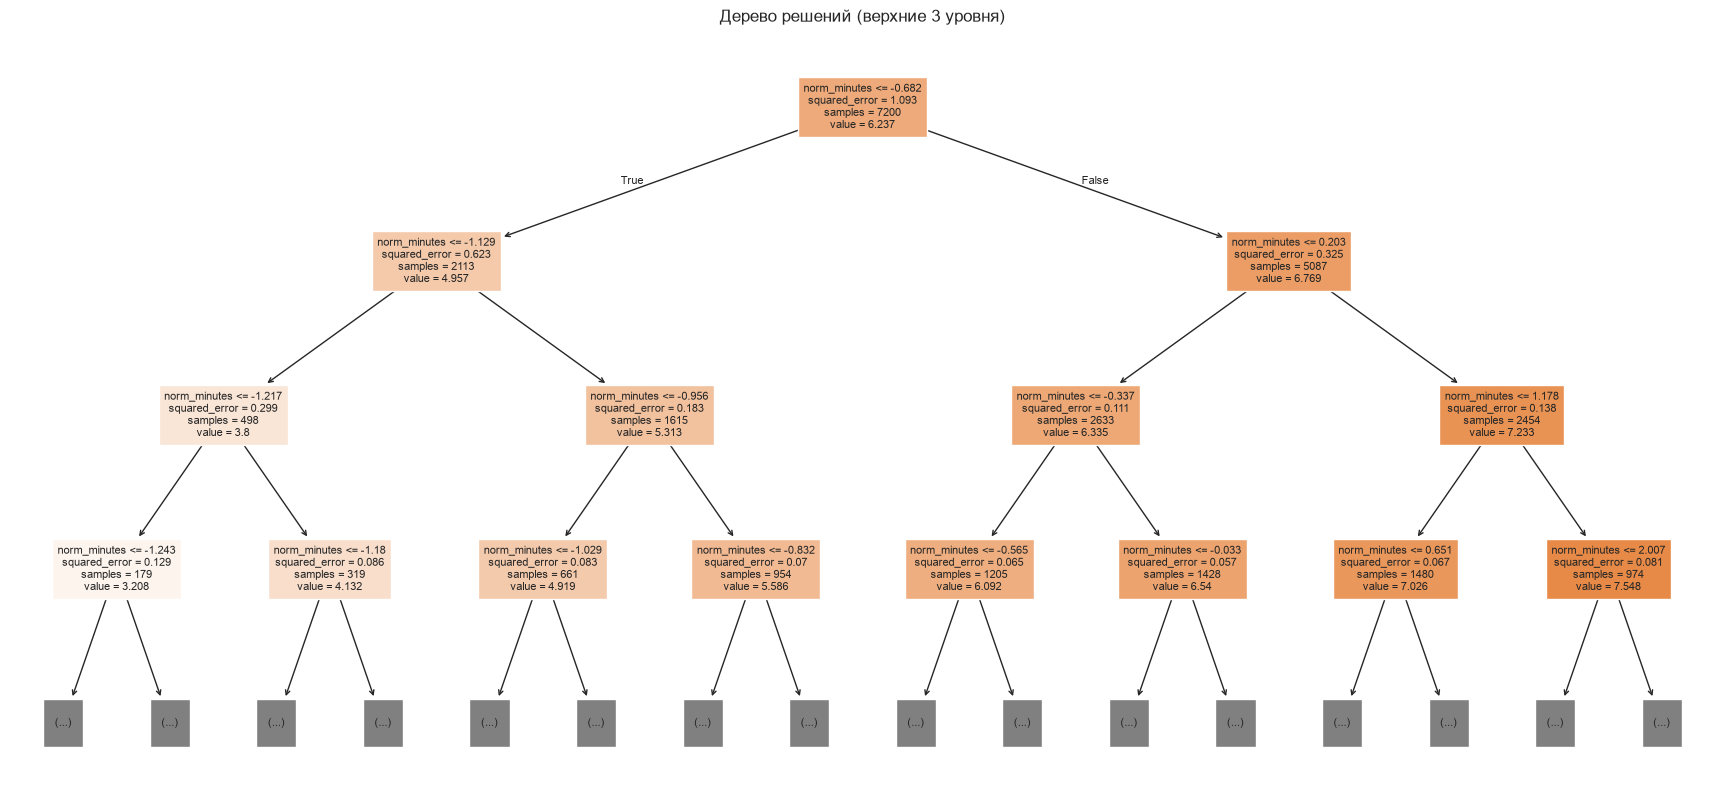

In [13]:
# Визуализация верхних уровней дерева (первые 3 уровня, иначе нечитаемо)
feature_names = (
    numeric_cols
    + list(tree_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_cols))
)

plt.figure(figsize=(22, 10))
plot_tree(
    tree_pipe.named_steps["model"],
    max_depth=3,
    feature_names=feature_names,
    filled=True,
    fontsize=8,
)
plt.title("Дерево решений (верхние 3 уровня)")
plt.show()


## 6. Ансамбли: Random Forest и Градиентный бустинг

Сравниваем классический ансамбль (Random Forest, бэггинг) и градиентный бустинг
(sklearn GradientBoosting, плюс CatBoost — он особенно удобен для категориальных признаков
без ручного OneHot).

In [14]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf_pipe = Pipeline([("prep", preprocess), ("model", RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1))])
results.append(evaluate(rf_pipe, "Random Forest", X_train, y_train, X_val, y_val))

gb_pipe = Pipeline([("prep", preprocess), ("model", GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42))])
results.append(evaluate(gb_pipe, "Gradient Boosting (sklearn)", X_train, y_train, X_val, y_val))


Random Forest: train MAE = 88.4 / R2 = 0.952  |  val MAE = 112.7 / R2 = 0.916


Gradient Boosting (sklearn): train MAE = 95.0 / R2 = 0.943  |  val MAE = 98.9 / R2 = 0.936


In [15]:
# CatBoost: в Colab доступен из коробки, локально может понадобиться `pip install catboost`
try:
    from catboost import CatBoostRegressor

    cat_features_idx = [X_train.columns.get_loc(c) for c in categorical_cols]

    cat_model = CatBoostRegressor(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="MAE",
        cat_features=cat_features_idx,
        verbose=False,
        random_state=42,
    )
    cat_model.fit(X_train, y_train)

    pred_train_min = np.expm1(cat_model.predict(X_train))
    train_mae = mean_absolute_error(np.expm1(y_train), pred_train_min)
    train_r2 = r2_score(np.expm1(y_train), pred_train_min)

    pred_val_min = np.expm1(cat_model.predict(X_val))
    true_val_min = np.expm1(y_val)
    mae = mean_absolute_error(true_val_min, pred_val_min)
    r2 = r2_score(true_val_min, pred_val_min)

    print(f"CatBoost: train MAE = {train_mae:.1f} / R2 = {train_r2:.3f}  |  val MAE = {mae:.1f} / R2 = {r2:.3f}")
    results.append({
        "name": "CatBoost", "model": cat_model,
        "train_mae": train_mae, "train_r2": train_r2,
        "mae": mae, "r2": r2,
    })
except ImportError:
    print("CatBoost не установлен — в Colab выполните: !pip install catboost")


CatBoost: train MAE = 93.7 / R2 = 0.943  |  val MAE = 99.7 / R2 = 0.935


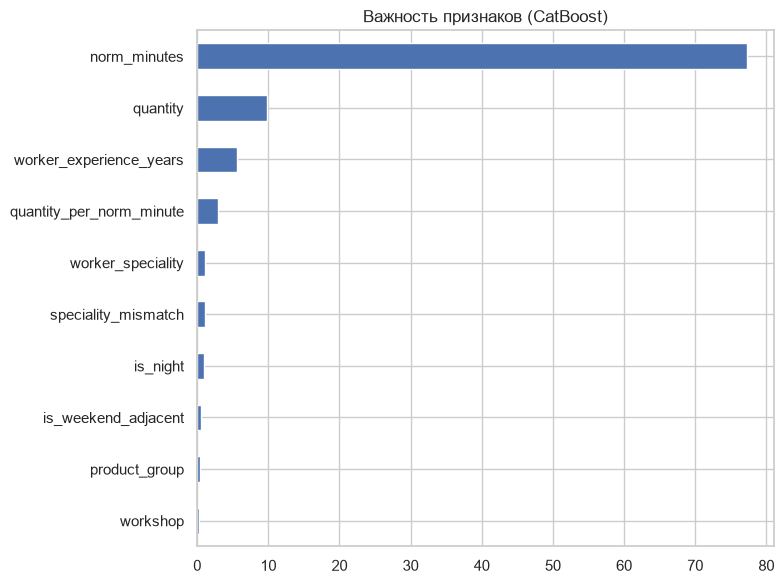

In [16]:
# Важность признаков по CatBoost (если обучился)
try:
    importances = pd.Series(cat_model.get_feature_importance(), index=X_train.columns).sort_values()
    importances.plot(kind="barh", figsize=(8, 6), title="Важность признаков (CatBoost)")
    plt.tight_layout()
    plt.show()
except NameError:
    pass


## 7. Метод опорных векторов (SVR)

SVM/SVR плохо масштабируется на десятки тысяч строк, поэтому обучаем на подвыборке —
как демонстрация метода и baseline для сравнения на малых данных (сценарий, когда
реальных исторических записей мало, например для нового цеха).

In [17]:
from sklearn.svm import SVR

sample_idx = X_train.sample(n=min(2000, len(X_train)), random_state=42).index
X_train_small = X_train.loc[sample_idx]
y_train_small = y_train.loc[sample_idx]

svr_pipe = Pipeline([("prep", preprocess), ("model", SVR(kernel="rbf", C=10, epsilon=0.05))])
results.append(evaluate(svr_pipe, "SVR (2000 строк)", X_train_small, y_train_small, X_val, y_val))


SVR (2000 строк): train MAE = 71.2 / R2 = 0.969  |  val MAE = 136.6 / R2 = 0.866


## 8. Понижение размерности (PCA) + кластеризация рабочих

Строим отдельный агрегированный датасет "один рабочий = одна строка" (средняя
эффективность по разным условиям) и ищем скрытые группы производительности:
иерархическая кластеризация (дендрограмма) и DBSCAN (для выявления аномальных рабочих —
выбросов, а не для основных кластеров).

In [18]:
worker_profile = (
    data.groupby("worker_id")
    .agg(
        avg_ratio=("ratio", "mean"),
        std_ratio=("ratio", "std"),
        avg_quantity=("quantity", "mean"),
        n_tasks=("ratio", "count"),
        mismatch_rate=("speciality_mismatch", "mean"),
        night_rate=("is_night", "mean"),
    )
    .fillna(0)
)
worker_profile = worker_profile[worker_profile["n_tasks"] >= 10]  # достаточно наблюдений
worker_profile.head()


,avg_ratio,std_ratio,avg_quantity,n_tasks,mismatch_rate,night_rate
worker_id,,,,,,
1,1.396771,0.191055,265.943503,177,0.022599,0.214689
2,0.920584,0.158542,243.915493,142,0.056338,0.232394
3,0.962848,0.160285,263.818182,143,0.048951,0.272727
4,0.867979,0.126775,257.251613,155,0.051613,0.258065
5,1.162834,0.161691,235.413408,179,0.022346,0.229050


Объяснённая дисперсия: [0.32934846 0.27521661]


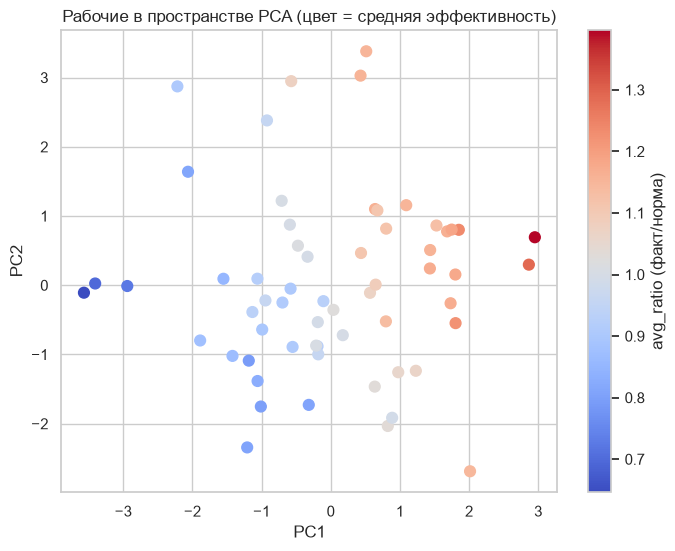

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_workers = scaler.fit_transform(worker_profile)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_workers)

print("Объяснённая дисперсия:", pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=worker_profile["avg_ratio"], cmap="coolwarm", s=60)
plt.colorbar(label="avg_ratio (факт/норма)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Рабочие в пространстве PCA (цвет = средняя эффективность)")
plt.show()


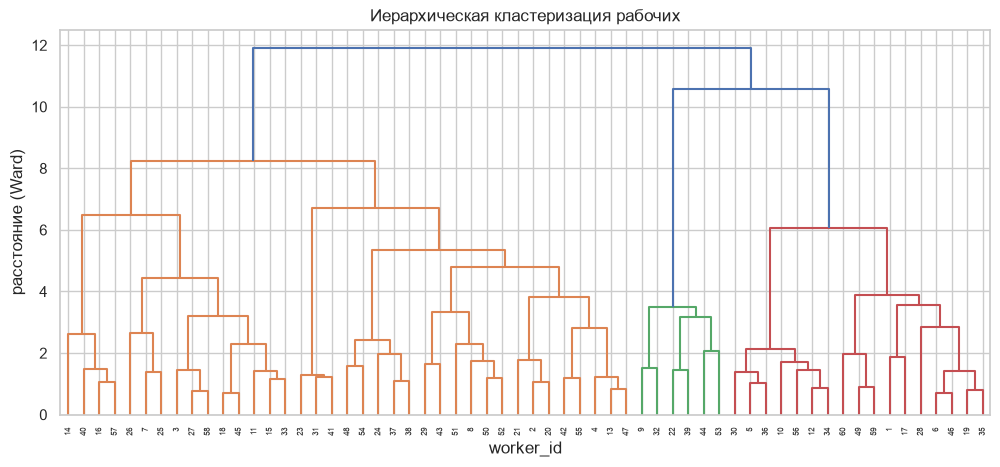

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_workers, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, labels=worker_profile.index.tolist())
plt.title("Иерархическая кластеризация рабочих")
plt.xlabel("worker_id")
plt.ylabel("расстояние (Ward)")
plt.show()


In [21]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=3)
labels = dbscan.fit_predict(X_workers)

worker_profile["dbscan_cluster"] = labels
print("Кластеры (-1 = выброс/аномальный рабочий):")
print(worker_profile["dbscan_cluster"].value_counts())

worker_profile[worker_profile["dbscan_cluster"] == -1].sort_values("avg_ratio", ascending=False)


Кластеры (-1 = выброс/аномальный рабочий):
dbscan_cluster
 0    36
-1    15
 2     3
 1     3
 3     3
Name: count, dtype: int64


,avg_ratio,std_ratio,avg_quantity,n_tasks,mismatch_rate,night_rate,dbscan_cluster
worker_id,,,,,,,
1,1.396771,0.191055,265.943503,177,0.022599,0.214689,-1
28,1.291106,0.214346,249.550420,238,0.063025,0.239496,-1
17,1.169712,0.166586,269.825301,166,0.018072,0.204819,-1
14,1.146011,0.192836,257.239130,138,0.115942,0.253623,-1
60,1.064395,0.186452,278.377483,151,0.052980,0.264901,-1
21,1.056372,0.170650,242.343750,160,0.081250,0.218750,-1
48,1.001239,0.145471,263.098814,253,0.011858,0.268775,-1
32,0.958566,0.138401,251.761658,386,0.018135,0.230570,-1
24,0.929901,0.162396,271.774590,244,0.045082,0.254098,-1


Рабочие с меткой `-1` — статистические выбросы по совокупности признаков
(эффективность, стабильность, доля несоответствия специальности, доля ночных смен).
В реальном проекте это кандидаты на точечную проверку: либо системная проблема
(неправильно закреплена специальность), либо реальный аутлайер по производительности.

## 9. Борьба с переобучением: train vs validation, кривая обучения

Сравниваем метрику на train и на validation для каждой модели — большой разрыв
(train намного лучше val) говорит о переобучении. Затем строим **кривую обучения**
(learning curve) для лучшей модели по validation-метрике: как MAE на train и на
validation меняется с ростом размера обучающей выборки. Если кривые расходятся и не
сходятся — модель переобучена и ей либо нужно больше данных, либо нужна регуляризация
(меньше глубина/итераций, больше `min_samples_leaf`, ниже `learning_rate` и т.п.).

In [22]:
overfit_table = pd.DataFrame([
    {
        "model": r["name"],
        "train_MAE": r["train_mae"],
        "val_MAE": r["mae"],
        "gap_MAE": r["mae"] - r["train_mae"],
        "train_R2": r["train_r2"],
        "val_R2": r["r2"],
        "gap_R2": r["train_r2"] - r["r2"],
    }
    for r in results
]).sort_values("val_MAE")
overfit_table


,model,train_MAE,val_MAE,gap_MAE,train_R2,val_R2,gap_R2
3,Gradient Boosting (sklearn),95.033619,98.949884,3.916265,0.943473,0.935777,0.007695
4,CatBoost,93.747265,99.691927,5.944662,0.942657,0.934631,0.008027
2,Random Forest,88.418303,112.702936,24.284633,0.951797,0.915779,0.036018
1,Decision Tree,126.303486,129.583160,3.279674,0.897856,0.887004,0.010852
5,SVR (2000 строк),71.151660,136.628120,65.476460,0.969455,0.866093,0.103362
0,Linear Regression,218.190894,215.762746,-2.428148,0.669416,0.699614,-0.030198


Разрыв (`gap_MAE`, `gap_R2`) — главный индикатор переобучения:
- маленький разрыв + хорошая val-метрика → модель обобщает нормально;
- маленький разрыв + плохая val-метрика (и плохая train-метрика) → недообучение
  (модель слишком простая — это видно на Linear Regression);
- большой разрыв (train намного лучше val) → переобучение (типично для Decision Tree
  и в меньшей степени для Random Forest без ограничения глубины).

Лучшая модель по validation MAE: Gradient Boosting (sklearn)


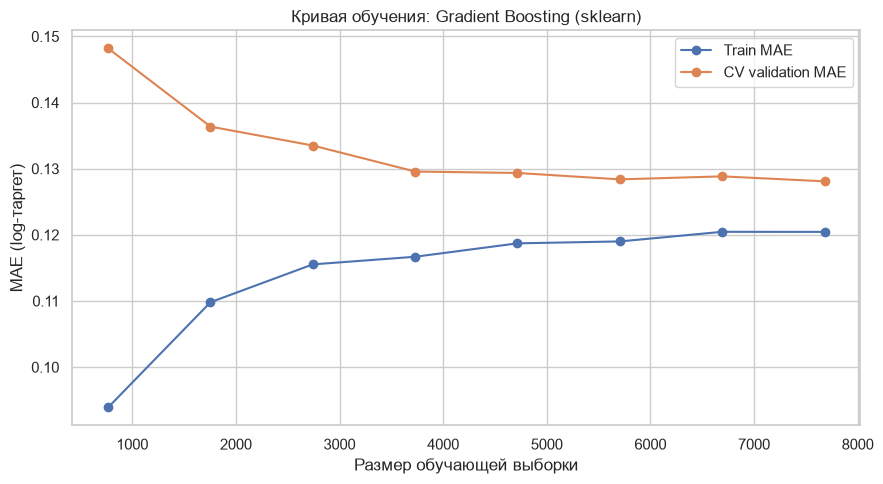

In [23]:
from sklearn.model_selection import learning_curve

best_name = overfit_table.iloc[0]["model"]
best_pipe = next(r["model"] for r in results if r["name"] == best_name)
print("Лучшая модель по validation MAE:", best_name)

train_sizes, train_scores, val_scores = learning_curve(
    best_pipe,
    X_train_full, y_train_full,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
)

# scoring в log-пространстве и с отрицательным знаком — переводим в положительный MAE (лог-единицы)
train_mae_curve = -train_scores.mean(axis=1)
val_mae_curve = -val_scores.mean(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mae_curve, "o-", label="Train MAE")
plt.plot(train_sizes, val_mae_curve, "o-", label="CV validation MAE")
plt.xlabel("Размер обучающей выборки")
plt.ylabel("MAE (log-таргет)")
plt.title(f"Кривая обучения: {best_name}")
plt.legend()
plt.tight_layout()
plt.show()


Если кривые сходятся и обе выходят на плато — увеличение данных дальше не даст
большого выигрыша, модель близка к своему потолку при текущем наборе признаков.
Если же кривые расходятся всё сильнее — это признак переобучения, и в реальном
проекте стоит либо увеличить регуляризацию, либо собрать больше исторических заданий.

## 10. Итоговое сравнение моделей и финальная проверка на test

In [24]:
summary = pd.DataFrame([{"model": r["name"], "MAE_minutes": r["mae"], "R2": r["r2"]} for r in results])
summary = summary.sort_values("MAE_minutes")
summary


,model,MAE_minutes,R2
3,Gradient Boosting (sklearn),98.949884,0.935777
4,CatBoost,99.691927,0.934631
2,Random Forest,112.702936,0.915779
1,Decision Tree,129.583160,0.887004
5,SVR (2000 строк),136.628120,0.866093
0,Linear Regression,215.762746,0.699614


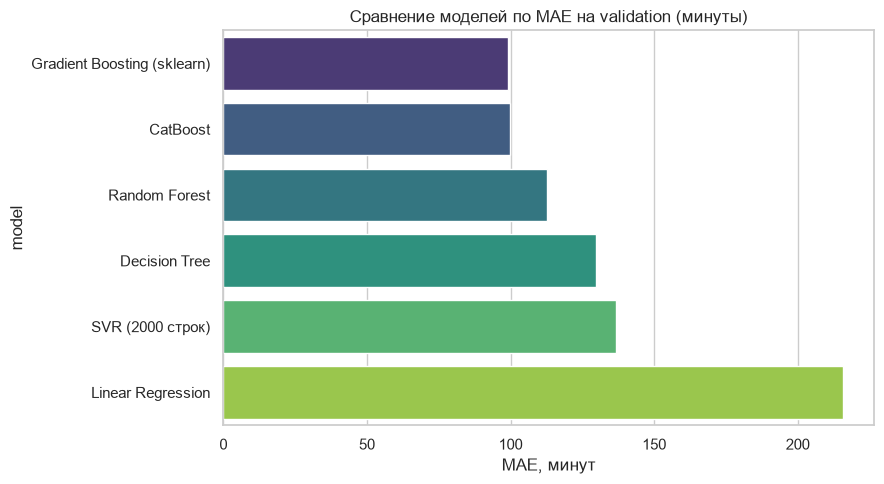

In [25]:
plt.figure(figsize=(9, 5))
sns.barplot(data=summary, x="MAE_minutes", y="model", hue="model", palette="viridis", legend=False)
plt.title("Сравнение моделей по MAE на validation (минуты)")
plt.xlabel("MAE, минут")
plt.tight_layout()
plt.show()


### Финальная оценка на test

Test использовался только один раз — здесь. Он не участвовал ни в выборе модели,
ни в подборе гиперпараметров, поэтому даёт несмещённую оценку того, как модель
поведёт себя на новых данных.

In [26]:
pred_test_min = np.expm1(best_pipe.predict(X_test))
true_test_min = np.expm1(y_test)

test_mae = mean_absolute_error(true_test_min, pred_test_min)
test_r2 = r2_score(true_test_min, pred_test_min)

print(f"{best_name} на test: MAE = {test_mae:.1f} мин, R2 = {test_r2:.3f}")
print(f"Для сравнения на validation было: MAE = {overfit_table.iloc[0]['val_MAE']:.1f} мин, R2 = {overfit_table.iloc[0]['val_R2']:.3f}")


Gradient Boosting (sklearn) на test: MAE = 98.2 мин, R2 = 0.941
Для сравнения на validation было: MAE = 98.9 мин, R2 = 0.936


Близкие значения MAE/R2 на validation и test подтверждают, что модель не была
переобучена под validation при выборе гиперпараметров/алгоритма — иначе test-метрика
оказалась бы заметно хуже.

## Выводы и возможные развития

- Лучшая модель по MAE — см. таблицу выше; обычно градиентный бустинг (CatBoost/GradientBoosting)
  выигрывает у линейной регрессии и одиночного дерева за счёт нелинейных взаимодействий
  (несоответствие специальности × ночная смена и т.п.).
- Дерево решений полезно не по точности, а по интерпретируемости — правила можно показать
  мастеру цеха напрямую.
- SVR на малой подвыборке — ориентир для сценария "мало исторических данных" (новый цех/линия).
- PCA + иерархическая кластеризация + DBSCAN — находят скрытые группы рабочих по эффективности
  и аномалии, не требуя разметки.

**Следующие шаги на реальных данных ASPMK:**
1. Заменить синтетический датасет на выгрузку из `task_assignments` + `production_tasks`
   (JOIN по `task_id`, `worker_id`, `workshop_id`, `entity_id`/`entity_type`).
2. Добавить признак `route_sheet` этапа (какая именно операция из `route_sheets.operations`).
3. Валидировать модель на данных "будущего периода" (time-based split), а не случайном сплите —
   в проде важно, чтобы модель работала на данных, которых не было в момент обучения.
4. Развернуть лучшую модель как отдельный сервис/эндпоинт, который пересчитывает
   ожидаемый `end_date` для `production_tasks` при создании задания.
